In [1]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sb
from os import mkdir
import os
import warnings
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data
import random

In [2]:
sc.set_figure_params(dpi=60, 
                     dpi_save=300, 
                     color_map= 'viridis_r')
plt.rcParams['figure.figsize']=(6,6) #rescale figures
plt.rcParams['grid.alpha']=0
sc.settings.verbosity = 3
sc.logging.print_header()

scanpy==1.9.5 anndata==0.10.2 umap==0.5.4 numpy==1.26.1 scipy==1.11.3 pandas==2.1.1 scikit-learn==1.3.1 statsmodels==0.14.0 pynndescent==0.5.10


In [3]:
#print shape of the matrix 
def shape(adata):
    print ('In the dataset there are:')
    print (f'{adata.obs.shape[0]} cells')
    print (f'{adata.var.shape[0]} genes')
    
## creating a boxplot to show the data distribution
def range_values_in_dataset (plot_title='Non normalized dataset'):
    tmp1=pd.DataFrame(adata.X)
    uniques=np.unique (tmp1)
    outliers_annotations = dict(markerfacecolor='g', marker='D', markersize=4, alpha=0.1,)
    box_annotations= dict(linewidth=1, color='blue', alpha=0.9 , facecolor='teal' )
    plt.boxplot (uniques, patch_artist=True, 
                 flierprops=outliers_annotations, 
                 boxprops= box_annotations )
    plt.ylabel('Unique range of values in the dataset ')
    plt.title (plot_title) ## you can notice it because the range is large
    plt.tick_params(labelbottom=False, bottom=False)
    sb.displot(uniques, kind="kde", legend=False)
    plt.tick_params(labelleft=False, left=False, )
    del uniques, tmp1

#Check how many genes form the ones we want to analyze remain after filtering
def genes_in_dataset (genes_list, dataset,):
    global found_genes
    global no_found_genes
    found_genes=[]
    no_found_genes=[]
    for gene in genes_list:
        if gene in dataset.raw.var_names:
            found_genes.append (gene)
        else:
            no_found_genes.append (gene, )
    #return found_genes, no_found_genes
    print (f'We found {len (found_genes)} out of {len(ALL_GENES)}')
    print (f'These genes are not in the datset: {no_found_genes}')

In [4]:
#Genes that we are analyzing
ALL_GENES=['oc', 'Optix', 'tll', 'Lim1', 'scro', 'Gsc', 'Rx','hh', 'wg', 'ci', 'mirr', 'ems', 'ey','erm','slp1','slp2'
         , 'Dbx', 'Ptx1', 'ths', 'pyr', 'htl', 'fd102C', 'so', 'Six4','Lim3', 'eya']
genes_homeobox=['lab', 'pb', 'Dfd', 'Scr', 'Antp', 'Ubx', 'abd-A', 'Abd-B' ] 


In [5]:
%%time
#Reading the filtered dataset
data_file='./3_tribolium_neuroblast_dataset/2_tribolium_neuroblasts_normalized_and_log_dataset.h5ad'
adata = sc.read_h5ad(data_file)


CPU times: user 166 ms, sys: 687 ms, total: 853 ms
Wall time: 852 ms


In [6]:
annotations = pd.read_csv("../integration_dataset_and_annotation/cell_annotation_brain_NBs_1_Drosophila_and_Tribolium_label_transfer.csv", index_col=0)
annotations.columns = ['cell_types', 'dataset']
annotations = annotations[annotations['dataset'] != 'drosophila']
annotations = annotations.rename_axis('cell_id')
annotations.drop('dataset', axis=1, inplace=True)
#annotations

adata.obs['cell_types'] = (
    annotations.reindex(adata.obs_names)
    .fillna('Unknown'))

#Removed unwanted cells in brain neuroblasts
cell_types_to_remove = [
    'Midline_NBs', 
    'PCGs', 
    'Sensory NBs', 
    'plasmatocytes/embryonic hemocytes/macrophages', 
    'Mesodermal/muscle progenitors'
]
# Filter out the cells
adata = adata[~adata.obs['cell_types'].isin(cell_types_to_remove)].copy()
adata.obs['cell_types'].value_counts()

cell_types
Unknown                           36963
GMC                                8391
NBs I                              3863
NBs II/INPs/newborn neurons_1?     2522
NBs II/INPs/newborn neurons_2?     1344
NBs II/INPs                         777
Name: count, dtype: int64

In [7]:
####Removing cells that do not have NBs gene markers
genes_of_interest= ['tGFP', 'ase', 'wor', 'dpn', 'pnt', 'pros']

# keep only genes that actually exist in the dataset
existing_genes= [g for g in genes_of_interest if g in adata.var_names]

print("Found genes:", existing_genes)

# boolean mask: cells expressing ANY of the genes (>0)
mask= np.any(adata[:, existing_genes].X.toarray() > 0, axis=1)

# filter AnnData
adata_filtered= adata[mask].copy()

adata= adata_filtered
del adata_filtered

Found genes: ['tGFP', 'ase', 'wor', 'dpn', 'pnt', 'pros']


In [8]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 34885 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'>

In [9]:
adata


AnnData object with n_obs × n_vars = 34885 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [10]:
adata_TF = adata[:, adata.var['is_TF'] == True].copy()
adata= adata_TF
adata

AnnData object with n_obs × n_vars = 34885 × 840
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [11]:
# Keep only genes NOT in genes_homeobox
adata_filtered = adata[:, ~adata.var_names.isin(genes_homeobox)].copy()
adata= adata_filtered
adata

AnnData object with n_obs × n_vars = 34885 × 832
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [12]:
##Recalling the raw data, that was saved originally in the layers['counts']
## This is necessary for the DE analysis
adata.X= adata.layers['counts']
adata.raw = adata

In [13]:
adata

AnnData object with n_obs × n_vars = 34885 × 832
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [14]:
#sc.pl.highest_expr_genes(adata, n_top=20, )

In [15]:
adata.obs_names_make_unique()

In [16]:
# Create an empty DataFrame to store the sums for each replicate
sums_per_replicate_df = pd.DataFrame(index=adata.var_names)

replicates_n = 15


for neuroblast in adata.obs.hox.unique():
    #check the two conditions: Hox and No_hox
    sample_subset = adata[adata.obs['hox'] == neuroblast]

    #Divide the indices (cells) of each condition in equal parts.
    #This indices are use to create pseudo replicates
    indices = list(sample_subset.obs_names)
    random.shuffle(indices)
    indices = np.array_split(np.array(indices), replicates_n)

    for i, pseudo_rep in enumerate(indices):
        #Subset the pseudoreplicates
        pseudo_rep_data = sample_subset[pseudo_rep, :].copy()
        pseudo_rep_data.obs['replicate'] = i

        # Sum the values for each gene across cells in the replicate
        sum_per_replicate = np.sum(pseudo_rep_data.X, axis=0).T

        # Store the sums in the DataFrame with gene names as indices
        sums_per_replicate_df[f'{str(neuroblast)}_{i+1}'] = sum_per_replicate

sums_per_replicate_df

,Hox_1,Hox_2,Hox_3,Hox_4,Hox_5,Hox_6,Hox_7,Hox_8,Hox_9,Hox_10,...,No_hox_6,No_hox_7,No_hox_8,No_hox_9,No_hox_10,No_hox_11,No_hox_12,No_hox_13,No_hox_14,No_hox_15
gene_names,,,,,,,,,,,,,,,,,,,,,
Hey,555.0,551.0,577.0,463.0,601.0,534.0,510.0,532.0,515.0,563.0,...,157.0,151.0,144.0,131.0,144.0,143.0,171.0,122.0,137.0,146.0
Klf15,2.0,3.0,6.0,1.0,5.0,2.0,4.0,2.0,1.0,3.0,...,0.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
erm,36.0,28.0,26.0,18.0,15.0,26.0,32.0,26.0,31.0,38.0,...,17.0,20.0,22.0,23.0,16.0,22.0,31.0,29.0,25.0,24.0
CG10600,595.0,515.0,560.0,618.0,692.0,576.0,678.0,630.0,584.0,616.0,...,129.0,134.0,120.0,137.0,127.0,121.0,141.0,116.0,131.0,113.0
ewg,1423.0,1374.0,1395.0,1408.0,1556.0,1424.0,1463.0,1331.0,1365.0,1354.0,...,320.0,282.0,320.0,334.0,288.0,326.0,287.0,346.0,258.0,310.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TC031898,8.0,4.0,6.0,8.0,19.0,6.0,9.0,8.0,9.0,9.0,...,4.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0
TC031788,7.0,9.0,3.0,8.0,8.0,10.0,8.0,17.0,5.0,9.0,...,2.0,2.0,4.0,1.0,0.0,1.0,3.0,2.0,0.0,2.0
HLH54F,40.0,67.0,103.0,41.0,61.0,31.0,79.0,40.0,116.0,25.0,...,6.0,9.0,5.0,12.0,5.0,8.0,17.0,4.0,12.0,6.0


In [17]:
counts= sums_per_replicate_df.T
counts

gene_names,Hey,Klf15,erm,CG10600,ewg,TC001633,vri,onecut,TC016055,BORCS6,...,grn,sqz,TC004259,TC031009,TC005199,TC031898,TC031788,HLH54F,TC002340,CG10984
Hox_1,555.0,2.0,36.0,595.0,1423.0,115.0,39.0,1214.0,219.0,89.0,...,2752.0,1667.0,6937.0,6.0,51.0,8.0,7.0,40.0,690.0,464.0
Hox_2,551.0,3.0,28.0,515.0,1374.0,113.0,34.0,1193.0,218.0,86.0,...,2739.0,1604.0,6810.0,20.0,48.0,4.0,9.0,67.0,683.0,434.0
Hox_3,577.0,6.0,26.0,560.0,1395.0,138.0,31.0,1255.0,248.0,78.0,...,2717.0,2020.0,7249.0,20.0,56.0,6.0,3.0,103.0,730.0,492.0
Hox_4,463.0,1.0,18.0,618.0,1408.0,117.0,23.0,1291.0,258.0,86.0,...,2595.0,1563.0,6931.0,15.0,45.0,8.0,8.0,41.0,707.0,474.0
Hox_5,601.0,5.0,15.0,692.0,1556.0,126.0,48.0,1285.0,229.0,80.0,...,2765.0,1554.0,7064.0,11.0,61.0,19.0,8.0,61.0,756.0,504.0
Hox_6,534.0,2.0,26.0,576.0,1424.0,117.0,36.0,1157.0,225.0,75.0,...,2858.0,1573.0,6910.0,9.0,54.0,6.0,10.0,31.0,707.0,472.0
Hox_7,510.0,4.0,32.0,678.0,1463.0,110.0,40.0,1287.0,263.0,77.0,...,2564.0,1643.0,7592.0,7.0,48.0,9.0,8.0,79.0,808.0,466.0
Hox_8,532.0,2.0,26.0,630.0,1331.0,136.0,37.0,1260.0,225.0,86.0,...,2434.0,1845.0,6843.0,8.0,63.0,8.0,17.0,40.0,662.0,463.0
Hox_9,515.0,1.0,31.0,584.0,1365.0,128.0,35.0,1161.0,230.0,81.0,...,2248.0,1957.0,6720.0,9.0,44.0,9.0,5.0,116.0,684.0,421.0
Hox_10,563.0,3.0,38.0,616.0,1354.0,126.0,24.0,1221.0,213.0,77.0,...,2455.0,2029.0,6874.0,10.0,49.0,9.0,9.0,25.0,692.0,516.0


In [18]:
metadata= pd.DataFrame(counts.index)
metadata.rename(columns={0: "sample"}, inplace=True)
metadata['condition'] = metadata['sample'].apply(lambda x: 'No_hox' if 'No' in x else x.split('_')[0])
metadata.set_index('sample', inplace=True)
metadata['replicate'] = metadata.index.str.extract('(\d+)', expand=False)
metadata

,condition,replicate
sample,,
Hox_1,Hox,1
Hox_2,Hox,2
Hox_3,Hox,3
Hox_4,Hox,4
Hox_5,Hox,5
Hox_6,Hox,6
Hox_7,Hox,7
Hox_8,Hox,8
Hox_9,Hox,9


In [19]:
dds= DeseqDataSet( counts=counts, metadata= metadata, design_factors= 'condition')

/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


In [20]:
dds

AnnData object with n_obs × n_vars = 30 × 832
    obs: 'condition', 'replicate'
    obsm: 'design_matrix'

In [21]:
sc.pp.filter_genes(dds, min_cells=1)

filtered out 1 genes that are detected in less than 1 cells


In [22]:
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.16 seconds.

Fitting dispersion trend curve...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Refitting 0 outliers.



In [23]:
dds

AnnData object with n_obs × n_vars = 30 × 831
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', 'replaceable'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks'

computing PCA
    with n_comps=29
    finished (0:00:00)


/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


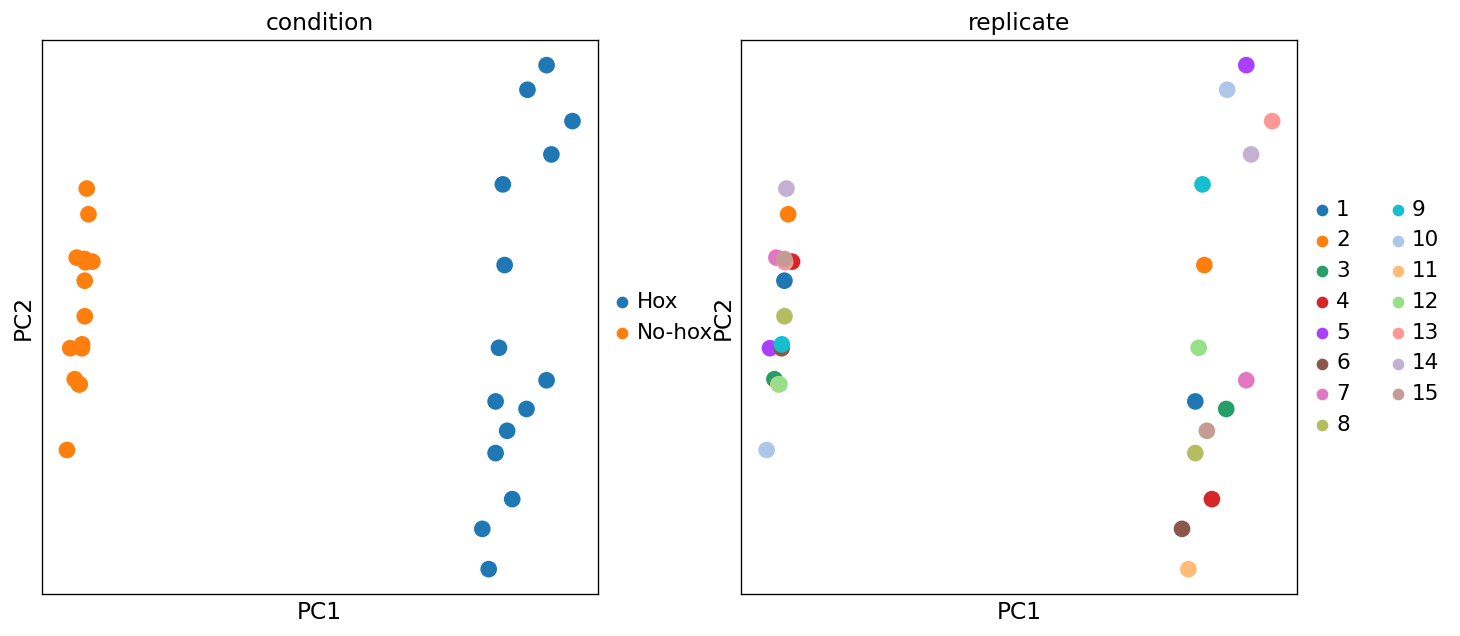

/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:324: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = ax.scatter(
/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:324: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = ax.scatter(


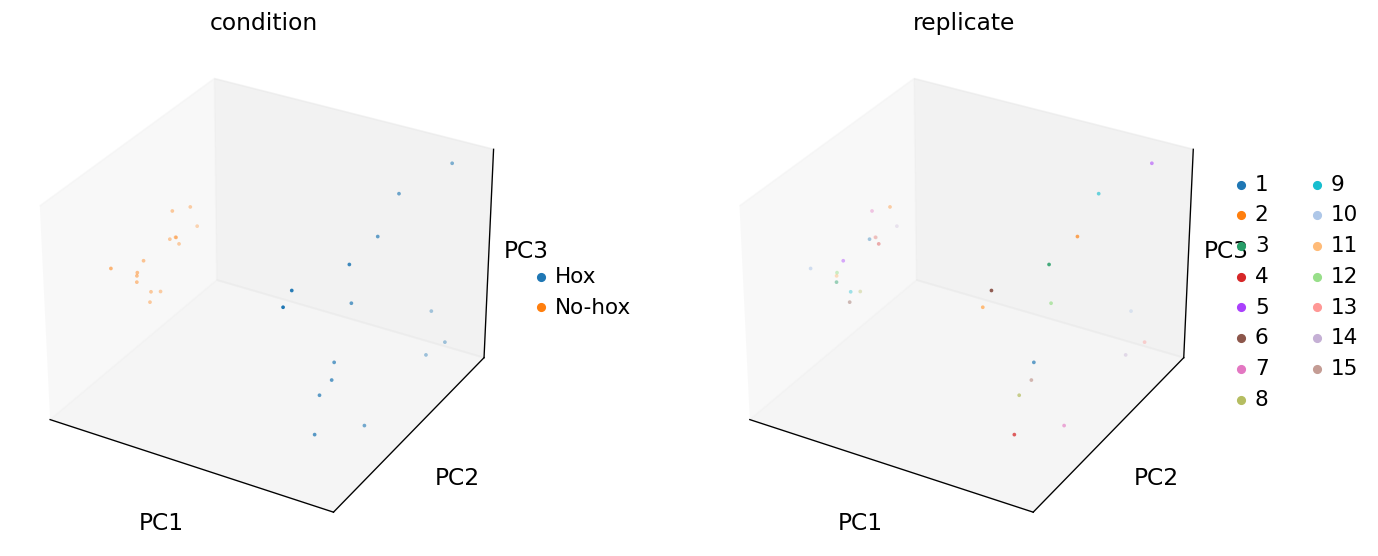

In [24]:
sc.tl.pca(dds)
sc.pl.pca(dds, color= ['condition', 'replicate'], size=400, projection='2d',)
sc.pl.pca(dds, color= ['condition', 'replicate'], size=200, projection='3d' ,)

In [25]:
stat_res= DeseqStats(dds, n_cpus=10, contrast= ('condition', 'No-hox', 'Hox') )
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition No-hox vs Hox


... done in 1.33 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
Hey,279.329204,0.288705,0.057049,5.060648,4.178349e-07,5.834766e-06
Klf15,1.291807,-0.608763,0.627352,-0.970368,3.318631e-01,5.581010e-01
erm,30.223231,1.935217,0.140912,13.733495,6.397188e-43,1.250650e-40
CG10600,279.617366,0.020858,0.044524,0.468463,6.394533e-01,8.078393e-01
ewg,648.985030,0.020987,0.027859,0.753325,4.512545e-01,6.633102e-01
...,...,...,...,...,...,...
TC031898,3.878400,-0.202740,0.338258,-0.599363,5.489307e-01,7.312842e-01
TC031788,3.623385,-0.026114,0.356978,-0.073153,9.416842e-01,9.715001e-01
HLH54F,23.406744,-0.558543,0.234476,-2.382090,1.721469e-02,6.939116e-02


In [26]:
de= stat_res.results_df
de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
Hey,279.329204,0.288705,0.057049,5.060648,4.178349e-07,5.834766e-06
Klf15,1.291807,-0.608763,0.627352,-0.970368,3.318631e-01,5.581010e-01
erm,30.223231,1.935217,0.140912,13.733495,6.397188e-43,1.250650e-40
CG10600,279.617366,0.020858,0.044524,0.468463,6.394533e-01,8.078393e-01
ewg,648.985030,0.020987,0.027859,0.753325,4.512545e-01,6.633102e-01
...,...,...,...,...,...,...
TC031898,3.878400,-0.202740,0.338258,-0.599363,5.489307e-01,7.312842e-01
TC031788,3.623385,-0.026114,0.356978,-0.073153,9.416842e-01,9.715001e-01
HLH54F,23.406744,-0.558543,0.234476,-2.382090,1.721469e-02,6.939116e-02


In [27]:
de.sort_values('stat', ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
oc,230.495818,1.121368,0.063752,17.589619,2.958605e-69,2.313629e-66
tll,32.362038,2.166205,0.131741,16.442917,9.427055e-61,3.685979e-58
toy,364.946278,0.986611,0.065617,15.036004,4.265337e-51,1.111831e-48
erm,30.223231,1.935217,0.140912,13.733495,6.397188e-43,1.250650e-40
Optix,111.478446,1.600279,0.118087,13.551648,7.747061e-42,1.211640e-39
...,...,...,...,...,...,...
TC006788,137.772837,-0.674718,0.076009,-8.876833,6.879084e-19,2.988580e-17
vnd,224.890595,-0.554838,0.061586,-9.009221,2.075255e-19,1.014281e-17
inv,321.458145,-0.560833,0.058444,-9.596155,8.298231e-22,4.991705e-20


In [28]:
#This is just to get rid of genes with low impact, it is mostl arbitrary
de=de[de.baseMean >= 10]

In [29]:
sigs= de[(de.padj < 0.05) & (abs(de.log2FoldChange) > 0.05)]
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
Hey,279.329204,0.288705,0.057049,5.060648,4.178349e-07,5.834766e-06
erm,30.223231,1.935217,0.140912,13.733495,6.397188e-43,1.250650e-40
TC014168,184.027993,0.195562,0.051415,3.803625,1.425939e-04,1.161546e-03
fd96Ca,35.267511,-0.498000,0.120310,-4.139322,3.483337e-05,3.492269e-04
HGTX,128.289775,-0.570361,0.069630,-8.191273,2.584775e-16,1.010647e-14
...,...,...,...,...,...,...
Phf5a,446.677660,0.145399,0.033744,4.308873,1.640887e-05,1.782185e-04
Fer3,12.022911,-0.717929,0.220356,-3.258037,1.121859e-03,7.372214e-03
TC010699,131.945981,0.223262,0.054577,4.090767,4.299490e-05,4.150865e-04


In [30]:
dds.layers['log1p']= np.log1p(dds.layers['normed_counts'])
dds

AnnData object with n_obs × n_vars = 30 × 831
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var', 'pca', 'condition_colors', 'replicate_colors'
    obsm: 'design_matrix', 'size_factors', 'replaceable', 'X_pca'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'PCs'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks', 'log1p'

In [31]:
dds_sigs= dds[:, sigs.index]
dds_sigs


View of AnnData object with n_obs × n_vars = 30 × 165
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var', 'pca', 'condition_colors', 'replicate_colors'
    obsm: 'design_matrix', 'size_factors', 'replaceable', 'X_pca'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'PCs'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks', 'log1p'

In [32]:
grapher=  pd.DataFrame(dds_sigs.layers['log1p'].T,
                        index=dds_sigs.var_names, columns=dds_sigs.obs_names)
grapher

sample,Hox_1,Hox_2,Hox_3,Hox_4,Hox_5,Hox_6,Hox_7,Hox_8,Hox_9,Hox_10,...,No_hox_6,No_hox_7,No_hox_8,No_hox_9,No_hox_10,No_hox_11,No_hox_12,No_hox_13,No_hox_14,No_hox_15
gene_names,,,,,,,,,,,,,,,,,,,,,
Hey,5.562017,5.559722,5.546415,5.352700,5.585469,5.541085,5.408001,5.519394,5.502546,5.550098,...,5.825846,5.843600,5.722924,5.651524,5.790997,5.742901,5.907303,5.556736,5.721315,5.755852
erm,2.880463,2.649633,2.526109,2.216052,2.031706,2.592626,2.704111,2.575961,2.754067,2.906715,...,3.626820,3.840859,3.862125,3.928178,3.617918,3.888575,4.211834,4.132318,4.034778,3.966256
TC014168,5.153082,5.163371,5.135983,5.140355,5.219226,5.154195,5.064316,5.197523,5.170787,5.057039,...,5.293471,5.349966,5.150100,5.504274,5.044100,5.325021,5.372739,5.242783,5.173184,5.295889
fd96Ca,3.894493,3.711525,3.792430,3.745005,3.810667,3.712300,3.649788,3.460313,3.909282,3.533035,...,3.626820,2.685780,3.610460,3.444313,3.163889,3.843030,3.501580,3.487937,3.765911,3.440700
HGTX,5.147663,5.085148,5.008478,4.931203,5.121346,5.062203,4.984112,4.939649,5.118232,5.116095,...,4.416383,4.724156,4.230227,4.544689,4.698476,4.717648,4.723088,4.746550,4.932423,4.871115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Phf5a,5.985777,6.096509,6.015818,6.055257,6.009946,6.028812,6.046700,6.064347,6.055697,6.130825,...,6.101607,6.113899,6.211429,6.154831,6.062203,6.208207,6.038305,6.201913,6.211708,6.204820
Fer3,2.739941,2.682284,2.997086,2.584494,2.950423,2.206591,3.046436,2.539779,2.894716,2.439647,...,1.668663,2.956273,1.994694,2.268342,2.053961,2.018072,2.461519,2.616473,1.169758,2.264996
TC010699,4.870914,4.695724,4.820381,4.904641,4.811683,4.840641,4.746167,4.799958,4.849407,4.735172,...,4.948155,4.973495,5.060264,4.891223,5.072903,4.678007,4.897544,5.045763,5.009443,4.980662


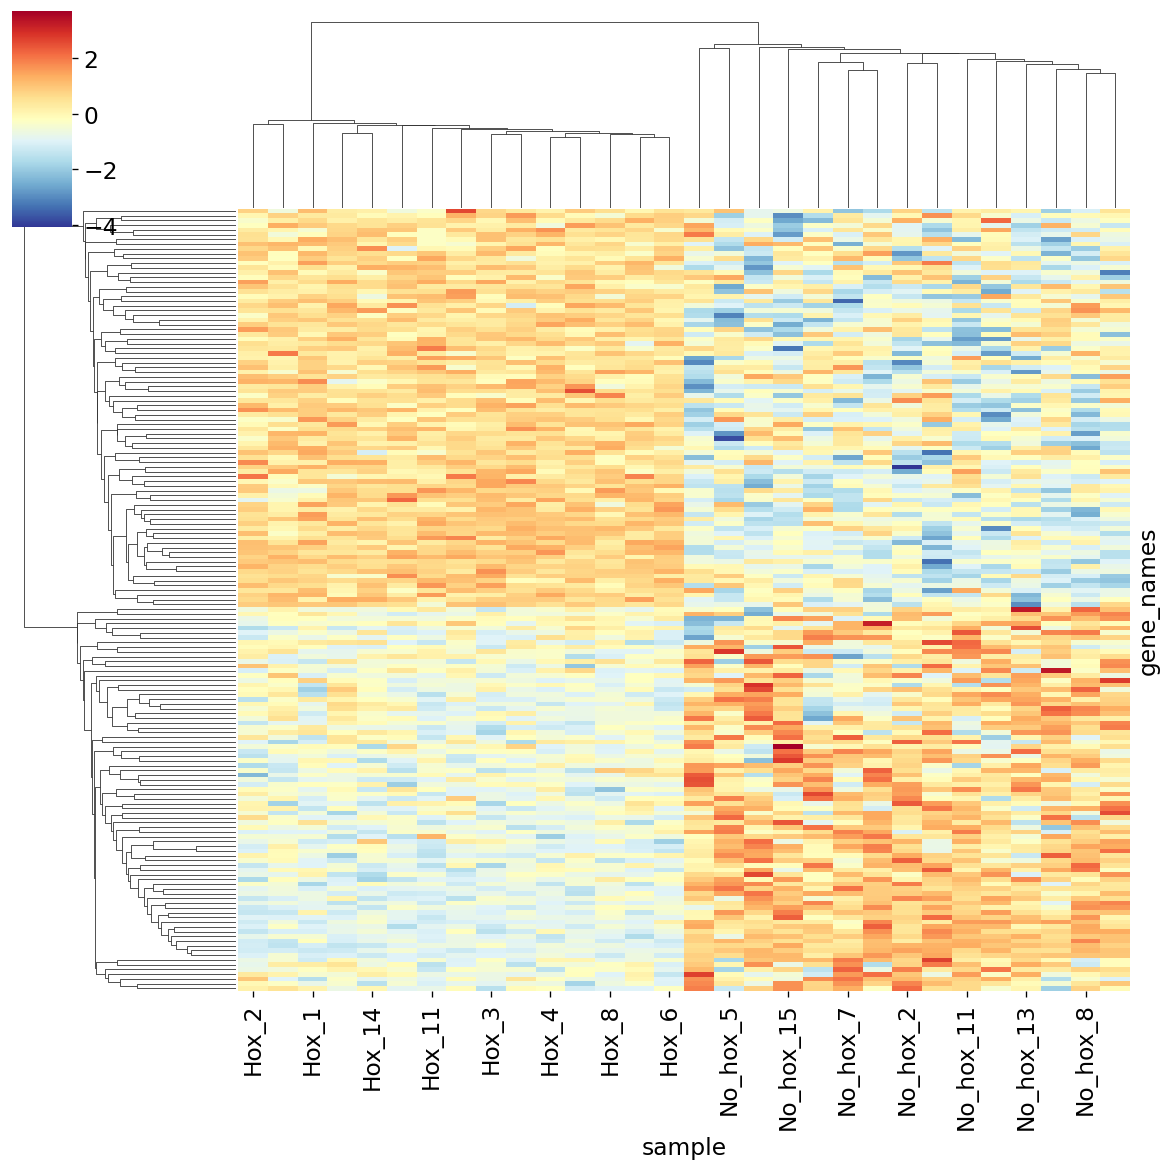

In [33]:
sb.clustermap(grapher, z_score=0,cmap= 'RdYlBu_r', yticklabels=False)

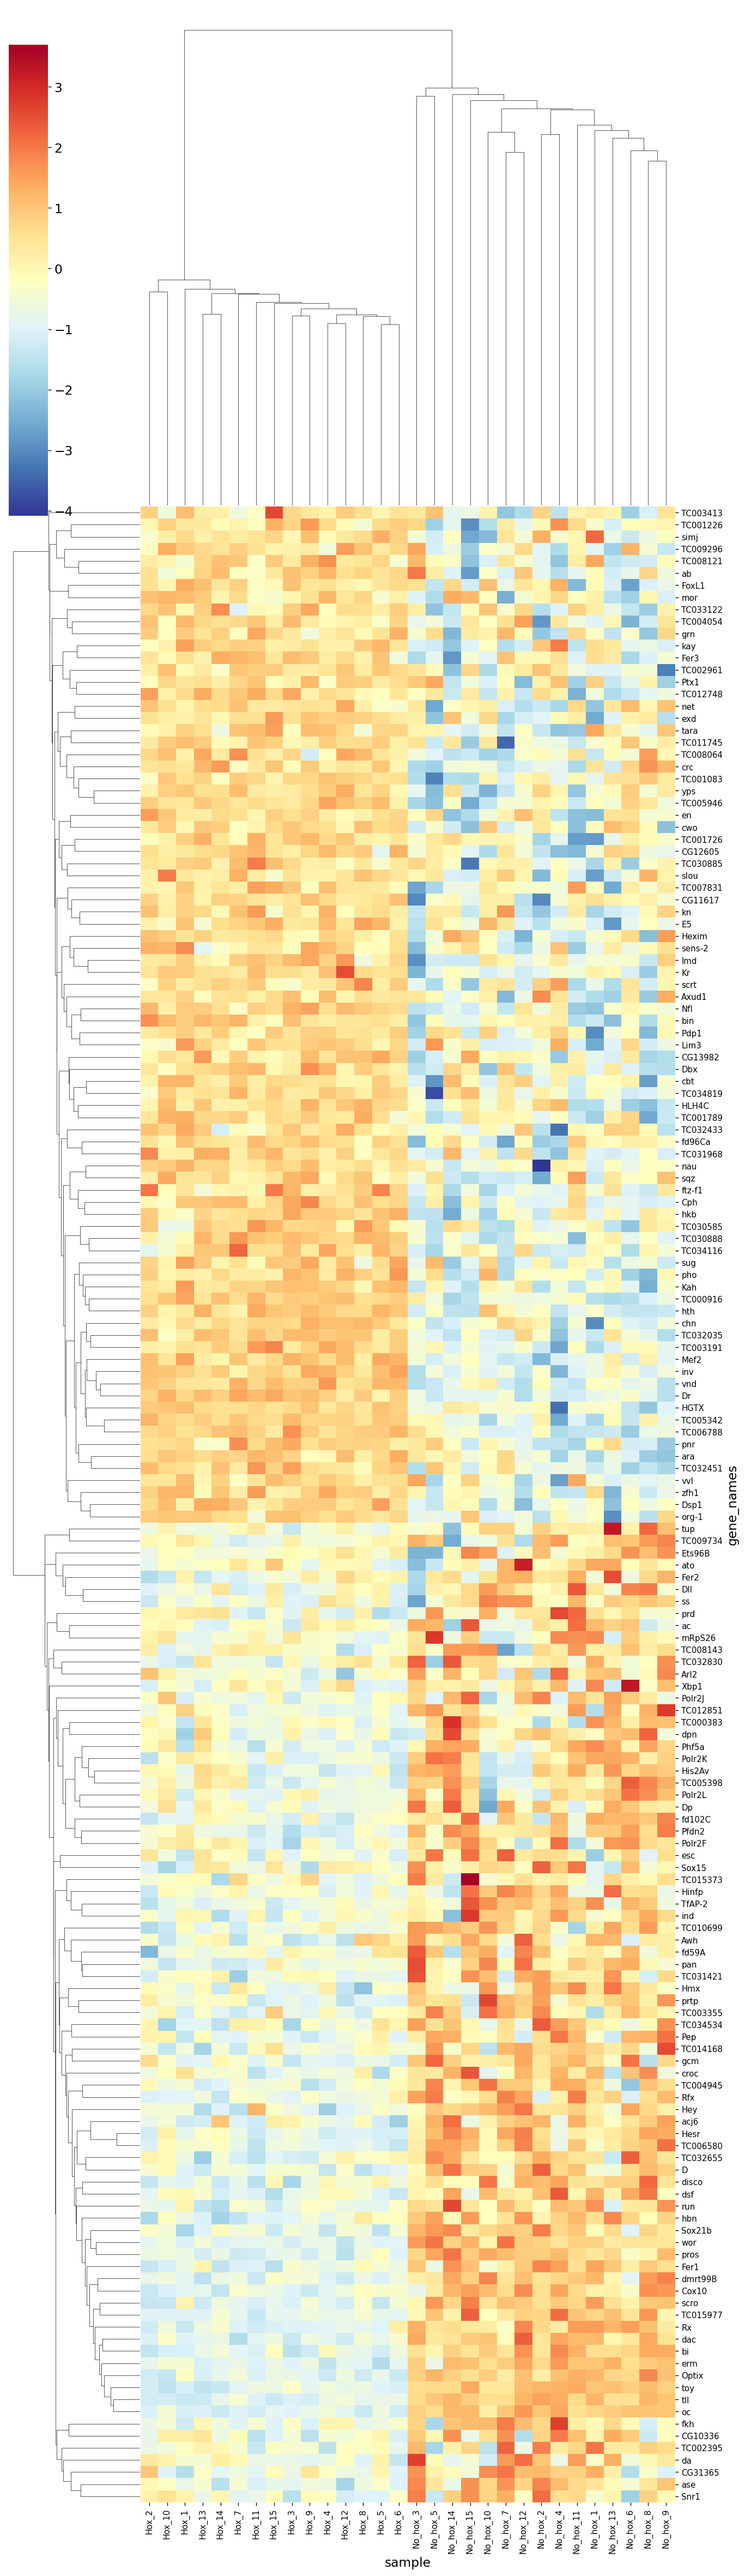

In [34]:
g = sb.clustermap(
    grapher,
    z_score=0,
    cmap='RdYlBu_r',
    figsize=(12, 40),       # adjust width/height as needed
    yticklabels=True,
    xticklabels=True,)

g.ax_heatmap.tick_params(labelsize=9)
g.fig.savefig("figures/heatmap_DE_TF_genes_tribolium_without_hox_genes_15_replicates.pdf", dpi=300, )

In [35]:
# Reordered row and column indices (as numpy arrays)
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

# Reorder the DataFrame according to the clustering order
ordered_data = grapher.iloc[row_order, col_order]

# Show the first few rows
print(ordered_data.head())

# Save to CSV if you want
ordered_data.to_csv('3_tribolium_neuroblast_dataset/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_tribolium15_replicates.csv')

sample         Hox_2    Hox_10     Hox_1    Hox_13    Hox_14     Hox_7  \
gene_names                                                               
TC003413    4.948344  4.556200  5.047763  4.795871  4.776342  4.550358   
TC001226    6.546039  6.593302  6.565100  6.566403  6.539794  6.551408   
simj        6.099675  6.138713  6.168854  6.133325  6.153510  6.140107   
TC009296    5.160681  5.309192  5.267816  5.245812  5.228279  5.261078   
TC008121    5.407717  5.389201  5.342072  5.446956  5.478140  5.472260   

sample        Hox_11    Hox_15     Hox_3     Hox_9  ...  No_hox_7  No_hox_12  \
gene_names                                          ...                        
TC003413    4.638986  5.473613  4.928500  4.834431  ...  4.135380   4.243119   
TC001226    6.535838  6.623519  6.592139  6.643925  ...  6.564621   6.491282   
simj        6.155655  6.172381  6.122230  6.195588  ...  6.153422   6.093054   
TC009296    5.231550  5.191824  5.196568  5.210411  ...  5.133397   5.245538   
T

In [36]:
#In case writing to save the file throws errir run this lines
filtered_data = dds.uns['trend_coeffs']

# Convert values to strings
dds.uns['trend_coeffs']= {key: str(value) for key, value in filtered_data.items()}
#In case writing to save the file throws error run this lines
for key, value in list(dds.varm.items()):
    if isinstance(value, pd.Series):
        dds.varm[key] = value.to_numpy().reshape(-1, 1)  # make 2D

### saving PyDEseq files
animal='tribolium'
gene_types= 'TFs_without_Hox'
folder= '3_tribolium_neuroblast_dataset'

pydesed_file= f'4_{gene_types}_PyDEseq_analysis_{animal}_15_replicates.h5ad' #This file is going to be used for the the downstream analysis
dds.write(pydesed_file)
os.system (f'mv {pydesed_file} {folder}')

0